In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import pandas as pd
import pyarrow.parquet as pq
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
import timm
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import pyarrow.parquet as pq
import pandas as pd
from torch.utils.checkpoint import checkpoint
import torch.nn.init as init
from torch.optim.lr_scheduler import StepLR
import dask.dataframe as dd
import numpy as np
import torch.nn as nn
import torch.optim as optim

In [3]:
#훈련 데이터 더 넣어주기
import pyarrow.parquet as pq
import pandas as pd
import numpy as np

# Set the size of each chunk in rows
chunk_size = 50

# 첫 번째 Parquet 파일 읽기
parquet_file_train_1 = pq.ParquetFile('/content/drive/MyDrive/machine learning/data/quak vs gluon/QCDToGGQQ_IMGjet_RH1all_jet0_run1_n47540.test.snappy.parquet')
total_rows_1 = parquet_file_train_1.metadata.num_rows

# 두 번째 Parquet 파일 읽기
parquet_file_train_2 = pq.ParquetFile('/content/drive/MyDrive/machine learning/data/quak vs gluon/QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494.test.snappy.parquet')  # 두 번째 파일 경로
total_rows_2 = parquet_file_train_2.metadata.num_rows

# 두 개의 데이터프레임 저장 리스트
dfs_1 = []
dfs_2 = []

# 첫 번째 파일 데이터를 읽어서 dfs_1에 저장
for i in range(0, total_rows_1, chunk_size):
    chunk = parquet_file_train_1.read_row_group(i)
    df = chunk.to_pandas()
    dfs_1.append(df)

# 두 번째 파일 데이터를 읽어서 dfs_2에 저장
for i in range(0, total_rows_2, chunk_size):
    chunk = parquet_file_train_2.read_row_group(i)
    df = chunk.to_pandas()
    dfs_2.append(df)

# 두 데이터프레임 병합
final_df_train_1 = pd.concat(dfs_1, ignore_index=True)
final_df_train_2 = pd.concat(dfs_2, ignore_index=True)

# 두 데이터프레임을 하나로 합침
final_df_train = pd.concat([final_df_train_1, final_df_train_2], ignore_index=True)

# 'X_jets' 컬럼을 변환
def to_3d(arr):
    arr = np.array(arr)  # 리스트를 numpy 배열로 변환
    if arr.shape == (3,):  # 현재 형태가 (3,)라면 변환 수행
        vishak = [np.stack(np.stack(channel), axis=-1) for channel in arr]
        return np.array(vishak, dtype=np.float32)  # 최종적으로 float32로 변환
    return arr  # 이미 올바른 형태면 그대로 반환

# 'X_jets' 컬럼을 변환
final_df_train['X_jets'] = final_df_train['X_jets'].apply(to_3d)

final_df_train['X_jets'][0], final_df_train['X_jets'][0].shape


(array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32),
 (3, 125, 125))

In [4]:
#test 데이터셋 로드
# Set the size of each chunk in rows
chunk_size = 50

# Create a Parquet file reader object
parquet_file_test = pq.ParquetFile('/content/drive/MyDrive/machine learning/data/quak vs gluon/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272.test.snappy.parquet')
# Determine the total number of rows in the file
total_rows = parquet_file_test.metadata.num_rows

# Loop over the file in chunks
dfs_test = []
for i in range(0, total_rows, chunk_size):
    # Read a chunk of rows from the file
    chunk = parquet_file_test.read_row_group(i)
    df_test = chunk.to_pandas()
#     print(i)
    dfs_test.append(df_test)

# Concatenate all the DataFrames into a single DataFrame
final_df_test = pd.concat(dfs_test, ignore_index=True)

parquet_file_test.read_row_group(0).to_pandas()

#(3,) 배열을 (3,125,125) 배열로 변환하기 위한 함수 정의
def to_3d(arr):
    vishak=[]
    for i in range (0,3):
        vis=np.stack(np.stack(arr)[i],axis=-1)
        vishak.append(vis)
    vishak=np.array(vishak)
    return vishak

for i in range (0,726):
    final_df_test['X_jets'][i]=to_3d(final_df_test['X_jets'][i])

final_df_test['X_jets'][0],final_df_test['X_jets'][0].shape #final_df['X_jets']은 변환된 3,125,125 배열

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  final_df_test['X_jets'][i]=to_3d(final_df_test['X_jets'][i])
<ipython-input-4-7e9bcb9778fc>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df_test['X_jets'][i]=to_3d(final_df_test['X_jets'][i])
<ipython-input-4-7e9bcb9778fc>:34: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a c

(array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]]),
 (3, 125, 125))

In [5]:
from torchvision import transforms
class ParquetDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe["X_jets"].values  # 이미지 데이터
        self.labels = dataframe["y"].values  # 라벨 데이터
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]  # (3, 125, 125) 형태의 이미지
        label = self.labels[idx]  # 정수형 라벨 (0 또는 1)

        if image.shape == (125, 125, 3):  # 🔥 (H, W, C) → (C, H, W) 변환
            image = image.transpose(2, 0, 1)  # (125,125,3) → (3,125,125)


        if isinstance(image, np.ndarray) and image.shape == (3, 125, 125):
            # 🔥 변환 전 데이터가 numpy 배열인지 확인
          image = torch.tensor(image, dtype=torch.float32)  # numpy → torch 변환

        if self.transform:
            image = self.transform(image)

        #손실함수 CrossEntropyLoss를 사용하기 위해서 라벨을 long 타입으로 변환
        label = torch.tensor(label,dtype=torch.long)

        return image, label


# 데이터 변환 (ViT 모델 입력 크기에 맞게 조정) -> 데이터 증강처리를 하면 정확도가 올라갈까?
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 먼저 충분히 크게 리사이즈
    #transforms.RandomHorizontalFlip(p=0.5),  # 좌우 반전 (50% 확률)
    #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # 색상 변화
    #transforms.RandomGrayscale(p=0.1),  # 일부 흑백 변환
    #transforms.ToTensor(),  # 텐서 변환
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # 정규화

])




In [6]:
from sklearn.model_selection import train_test_split

# 🚀 4️⃣ DataLoader 생성 (Colab RAM 절약)


# 🚀 학습/테스트 데이터 분할 (20% 테스트 데이터)
validation_df, test_df =train_test_split(final_df_test, test_size=0.5, random_state=42)

train_df=final_df_train
#test_df=final_df_test

BATCH_SIZE = 8


# 🚀 테스트용 Dataset & DataLoader 생성



# 🚀 수정된 코드
train_dataset = ParquetDataset(train_df, transform=transform)  # ✅ train_df만 사용
test_dataset = ParquetDataset(test_df, transform=transform)  # ✅ test_df만 사용
validation_dataset = ParquetDataset(validation_df, transform=transform)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=True)


print(f"✅ Train Samples: {len(train_df)}, Test Samples: {len(test_df)}")
print(f"Total training samples in dataset: {len(train_dataset)}")  # ✅ 363개여야 함
print(f"Total test samples in dataset: {len(test_dataset)}")  # ✅ 363개여야 함
print(f"Total validation samples in dataset: {len(validation_dataset)}")  # ✅ 363개여야 함

✅ Train Samples: 2061, Test Samples: 363
Total training samples in dataset: 2061
Total test samples in dataset: 363
Total validation samples in dataset: 363


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. 모델 불러오기 (timm을 사용하여 사전 학습된 ViT 모델 로드)
model_name = 'swin_large_patch4_window7_224'
model = timm.create_model(model_name, pretrained=True, drop_rate=0.2)

# 2. 출력 레이어 수정 (새로운 클래스 개수에 맞게 수정)
num_classes = 2  # 새로운 클래스 수
model.head = torch.nn.Linear(model.head.in_features, num_classes)

# 가중치 초기화
init.xavier_uniform_(model.head.weight)  # Xavier 초기화 (적절한 초기화 방법 선택)
init.zeros_(model.head.bias)
'''
# 1. 모델의 모든 파라미터를 학습 가능하게 설정
for param in model.parameters():
    param.requires_grad = True  # 모델의 모든 레이어를 학습
'''
# 4. 학습 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 옵티마이저와 손실 함수 설정 + L2 정규화 추가
#optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=5e-4)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)   #요 optimizer가 과적합을 줄이고 일반화 성능이 높다고 해서 써봤는데 미세하게 높음. (RAdam도 써볼 예정)
criterion = CrossEntropyLoss()

# Scheduler 설정 (옵션)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)

# 5. Fine-tuning 학습 (Gradient Checkpointing 적용)
def checkpointed_forward(model, image):
    # Forward pass with checkpointing to save memory
    image.requires_grad_()   #gradient 추적 활성화
    return checkpoint(model, image)

# 6. Fine-tuning 학습
for epoch in range(10):  # 에폭 수37분
    model.train()
    total_loss = 0
    for image, label in train_loader:
        image, label = image.to(device), label.to(device)

        # Forward pass with checkpointing
        outputs = checkpointed_forward(model, image)
        outputs = outputs.view(outputs.size(0), -1)  # [batch, num_classes]로 변환


        loss = criterion(outputs, label)
        total_loss += loss.item()

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)

    # Validation Step
    model.eval()
    val_loss = 0
    val_true_labels = []
    val_preds = []

    with torch.no_grad():
        for image, label in validation_loader:
            image, label = image.to(device), label.to(device)
            outputs = model(image)
            outputs = outputs.view(outputs.size(0), -1)  # [batch, num_classes]로 변환
            loss = criterion(outputs, label)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_true_labels.extend(label.cpu().numpy())
            val_preds.extend(predicted.cpu().numpy())

    avg_val_loss = val_loss / len(validation_loader)
    val_accuracy = accuracy_score(val_true_labels, val_preds)

    print(f"Epoch {epoch+1}: Validation Loss={avg_val_loss:.4f}, Validation Accuracy={val_accuracy:.4f}")
    print(f"Epoch {epoch + 1}, Loss: {avg_loss}")


    #scheduler.step()  # 학습률 조정 (옵션)

# 7. 학습 완료 후 모델 저장
torch.save(model.state_dict(), '/content/drive/MyDrive/machine learning/data/quak vs gluon/swin_model_large_train.pth')
print("Model saved successfully.")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/788M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 1: Validation Loss=0.7273, Validation Accuracy=0.5758
Epoch 1, Loss: 1.0242173911989196


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


...

Epoch 8: Validation Loss=0.6503, Validation Accuracy=0.6612
Epoch 8, Loss: 0.5149820552084797


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 9: Validation Loss=0.7705, Validation Accuracy=0.6501
Epoch 9, Loss: 0.4874712218667648


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 10: Validation Loss=0.7413, Validation Accuracy=0.6722
Epoch 10, Loss: 0.4630253540222035
Model saved successfully.


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. 모델 불러오기 (timm을 사용하여 사전 학습된 ViT 모델 로드)
model_name = 'swin_large_patch4_window7_224'
model = timm.create_model(model_name, pretrained=True, drop_rate=0.2)

# 2. 출력 레이어 수정 (새로운 클래스 개수에 맞게 수정)
num_classes = 2  # 새로운 클래스 수
model.head = torch.nn.Linear(model.head.in_features, num_classes)

# 가중치 초기화
init.xavier_uniform_(model.head.weight)  # Xavier 초기화 (적절한 초기화 방법 선택)
init.zeros_(model.head.bias)
'''
# 1. 모델의 모든 파라미터를 학습 가능하게 설정
for param in model.parameters():
    param.requires_grad = True  # 모델의 모든 레이어를 학습
'''
# 4. 학습 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 옵티마이저와 손실 함수 설정 + L2 정규화 추가
#optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=5e-4)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)   #요 optimizer가 과적합을 줄이고 일반화 성능이 높다고 해서 써봤는데 미세하게 높음. (RAdam도 써볼 예정)
criterion = CrossEntropyLoss()

# Scheduler 설정 (옵션)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)

# 5. Fine-tuning 학습 (Gradient Checkpointing 적용)
def checkpointed_forward(model, image):
    # Forward pass with checkpointing to save memory
    image.requires_grad_()   #gradient 추적 활성화
    return checkpoint(model, image)

# 6. Fine-tuning 학습
for epoch in range(15):  # 에폭 수
    model.train()
    total_loss = 0
    for image, label in train_loader:
        image, label = image.to(device), label.to(device)

        # Forward pass with checkpointing
        outputs = checkpointed_forward(model, image)
        outputs = outputs.view(outputs.size(0), -1)  # [batch, num_classes]로 변환


        loss = criterion(outputs, label)
        total_loss += loss.item()

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)

    # Validation Step
    model.eval()
    val_loss = 0
    val_true_labels = []
    val_preds = []

    with torch.no_grad():
        for image, label in validation_loader:
            image, label = image.to(device), label.to(device)
            outputs = model(image)
            outputs = outputs.view(outputs.size(0), -1)  # [batch, num_classes]로 변환
            loss = criterion(outputs, label)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_true_labels.extend(label.cpu().numpy())
            val_preds.extend(predicted.cpu().numpy())

    avg_val_loss = val_loss / len(validation_loader)
    val_accuracy = accuracy_score(val_true_labels, val_preds)

    print(f"Epoch {epoch+1}: Validation Loss={avg_val_loss:.4f}, Validation Accuracy={val_accuracy:.4f}")
    print(f"Epoch {epoch + 1}, Loss: {avg_loss}")


    #scheduler.step()  # 학습률 조정 (옵션)

# 7. 학습 완료 후 모델 저장
torch.save(model.state_dict(), '/content/drive/MyDrive/machine learning/data/quak vs gluon/swin_model_large_train_15.pth')
print("Model saved successfully.")

/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 1: Validation Loss=0.6820, Validation Accuracy=0.6061
Epoch 1, Loss: 1.0023535309835923


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 2: Validation Loss=0.7002, Validation Accuracy=0.6364
Epoch 2, Loss: 0.6379568366579307


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


...

Epoch 13: Validation Loss=0.8134, Validation Accuracy=0.6364
Epoch 13, Loss: 0.317716168672886


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 14: Validation Loss=0.9474, Validation Accuracy=0.6061
Epoch 14, Loss: 0.25932467323114244


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 15: Validation Loss=0.9045, Validation Accuracy=0.6061
Epoch 15, Loss: 0.22955720440318533
Model saved successfully.


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. 모델 불러오기 (timm을 사용하여 사전 학습된 ViT 모델 로드)
model_name = 'swin_large_patch4_window7_224'
model = timm.create_model(model_name, pretrained=True, drop_rate=0.2)

# 2. 출력 레이어 수정 (새로운 클래스 개수에 맞게 수정)
num_classes = 2  # 새로운 클래스 수
model.head = torch.nn.Linear(model.head.in_features, num_classes)

# 가중치 초기화
init.xavier_uniform_(model.head.weight)  # Xavier 초기화 (적절한 초기화 방법 선택)
init.zeros_(model.head.bias)
'''
# 1. 모델의 모든 파라미터를 학습 가능하게 설정
for param in model.parameters():
    param.requires_grad = True  # 모델의 모든 레이어를 학습
'''
# 4. 학습 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 옵티마이저와 손실 함수 설정 + L2 정규화 추가
#optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=5e-4)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)   #요 optimizer가 과적합을 줄이고 일반화 성능이 높다고 해서 써봤는데 미세하게 높음. (RAdam도 써볼 예정)
criterion = CrossEntropyLoss()

# Scheduler 설정 (옵션)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)

# 5. Fine-tuning 학습 (Gradient Checkpointing 적용)
def checkpointed_forward(model, image):
    # Forward pass with checkpointing to save memory
    image.requires_grad_()   #gradient 추적 활성화
    return checkpoint(model, image)

# 6. Fine-tuning 학습
for epoch in range(20):  # 에폭 수
    model.train()
    total_loss = 0
    for image, label in train_loader:
        image, label = image.to(device), label.to(device)

        # Forward pass with checkpointing
        outputs = checkpointed_forward(model, image)
        outputs = outputs.view(outputs.size(0), -1)  # [batch, num_classes]로 변환


        loss = criterion(outputs, label)
        total_loss += loss.item()

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)

    # Validation Step
    model.eval()
    val_loss = 0
    val_true_labels = []
    val_preds = []

    with torch.no_grad():
        for image, label in validation_loader:
            image, label = image.to(device), label.to(device)
            outputs = model(image)
            outputs = outputs.view(outputs.size(0), -1)  # [batch, num_classes]로 변환
            loss = criterion(outputs, label)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_true_labels.extend(label.cpu().numpy())
            val_preds.extend(predicted.cpu().numpy())

    avg_val_loss = val_loss / len(validation_loader)
    val_accuracy = accuracy_score(val_true_labels, val_preds)

    print(f"Epoch {epoch+1}: Validation Loss={avg_val_loss:.4f}, Validation Accuracy={val_accuracy:.4f}")
    print(f"Epoch {epoch + 1}, Loss: {avg_loss}")


    #scheduler.step()  # 학습률 조정 (옵션)

# 7. 학습 완료 후 모델 저장
torch.save(model.state_dict(), '/content/drive/MyDrive/machine learning/data/quak vs gluon/swin_model_large_train_15.pth')
print("Model saved successfully.")

In [7]:
# 테스트 파트
import torch
import timm
import numpy as np
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torch import nn
from sklearn.metrics import accuracy_score
from PIL import Image

# 1. 모델 불러오기 (timm을 사용하여 사전 학습된 ViT 모델 로드)
model_name = 'swin_large_patch4_window7_224'
model = timm.create_model(model_name, pretrained=False)

# 2. 출력 레이어 수정 (새로운 클래스 개수에 맞게 수정)
num_classes = 2  # 새로운 클래스 수
model.head = nn.Linear(model.head.in_features, num_classes)  # 출력 레이어 크기 변경

# 3. 저장된 모델의 가중치 불러오기
model.load_state_dict(torch.load('/content/drive/MyDrive/machine learning/data/quak vs gluon/swin_model_large_train_15.pth'))  # 모델 경로 수정

# 4. 모델을 GPU 또는 CPU로 이동
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 5. 모델 test 하기

def predict_image(image):
    model.eval()  # 모델을 평가 모드로 설정
    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)
    return predicted.item()

# 6. 테스트 데이터에 대해 정확도 평가

# 정확도 계산
true_label = []
pred_label = []

for image, label in test_loader:
    image, label = image.to(device), label.to(device)
    outputs = model(image)
    outputs = outputs.view(outputs.size(0), -1, outputs.size(-1))  # [8, h*w, num_classes] 형태로 변환
    #_, predicted = torch.max(outputs, 1)
    # 각 배치에서 가장 큰 값(로짓)을 가진 클래스 선택
    _, predicted = torch.max(outputs, dim=2)  # [8, h*w] 형태로 각 픽셀에 대해 예측된 클래스
    # 배치 내 예측값을 클래스별로 집계하여 하나의 예측값으로 계산
    # 예를 들어, 가장 많이 나온 클래스를 선택하거나 평균을 구할 수 있습니다.
    # 여기서는 가장 많이 나온 클래스를 선택하는 예시
    predicted_class = predicted.view(outputs.size(0), -1).mode(dim=1)[0]  # [8] 형태로 각 배치별 예측 클래스 선택

# 이제 `predicted_class`는 [8] 형태로, 각 배치의 최종 클래스를 가지고 있습니다.

    true_label.extend(label.cpu().numpy())
    pred_label.extend(predicted_class.cpu().numpy())

test_accuracy = accuracy_score(true_label, pred_label)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")



Test Accuracy: 60.33%


Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.81      0.69       188
           1       0.68      0.44      0.53       175

    accuracy                           0.63       363
   macro avg       0.64      0.62      0.61       363
weighted avg       0.64      0.63      0.62       363



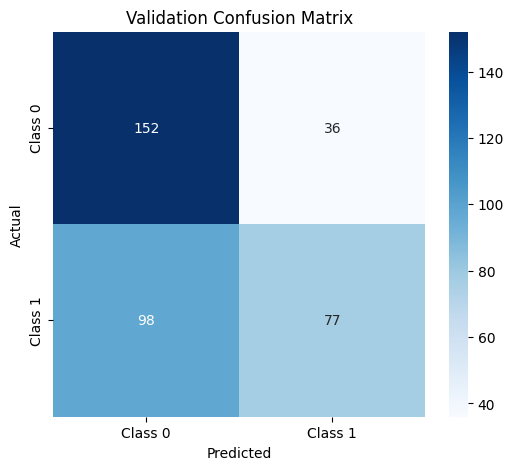

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Validation 데이터 평가
model.eval()
val_preds = []
val_true_labels = []

with torch.no_grad():
    for image, label in validation_loader:
        image, label = image.to(device), label.to(device)
        outputs = model(image)
        outputs = outputs.view(outputs.size(0), -1, outputs.size(-1))
        #_, predicted = torch.max(outputs, 1)
        _, predicted = torch.max(outputs, dim=2)
        predicted_class = predicted.view(outputs.size(0), -1).mode(dim=1)[0]

        val_true_labels.extend(label.cpu().numpy())
        val_preds.extend(predicted_class.cpu().numpy())

# Confusion Matrix 생성
cm = confusion_matrix(val_true_labels, val_preds)
print("Classification Report:")
print(classification_report(val_true_labels, val_preds))

# 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")
plt.show()


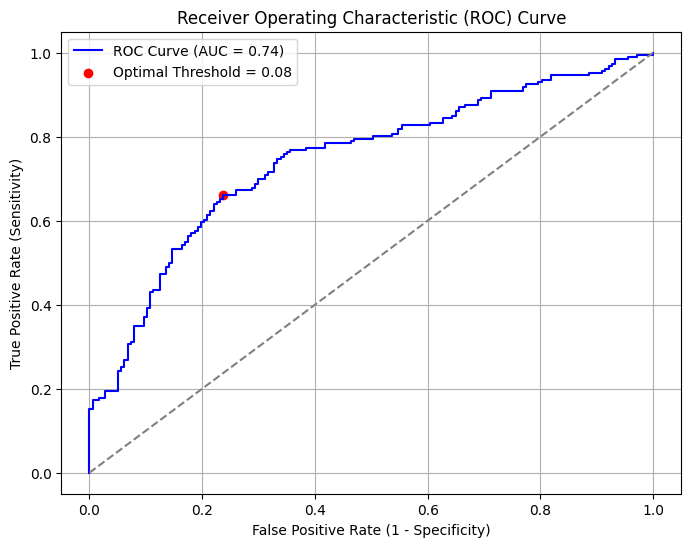

최적 Threshold: 0.0820


In [19]:
#ROC Curve 분석하여서 최적 임계값 찾기
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1️⃣ 모델 불러오기
# 1. 모델 불러오기 (timm을 사용하여 사전 학습된 ViT 모델 로드)
model_name = 'swin_large_patch4_window7_224'
model = timm.create_model(model_name, pretrained=False)

# 2. 출력 레이어 수정 (새로운 클래스 개수에 맞게 수정)
num_classes = 2  # 새로운 클래스 수
model.head = nn.Linear(model.head.in_features, num_classes)  # 출력 레이어 크기 변경

# 3. 저장된 모델의 가중치 불러오기
model.load_state_dict(torch.load('/content/drive/MyDrive/machine learning/data/quak vs gluon/swin_model_large_train.pth'))  # 모델 경로 수정

# 4. 모델을 GPU 또는 CPU로 이동
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

model.eval()  # 평가 모드

# 2️⃣ 실제 레이블과 예측 확률 저장
y_true = []
y_probs = []

with torch.no_grad():  # Gradient 계산 비활성화
    for image, label in test_loader:
        image, label = image.to(device), label.to(device)
        outputs = model(image)  # 모델 예측값
        outputs = torch.softmax(outputs.mean(dim=(1, 2)), dim=1)  # 공간 차원 평균 후 Softmax 적용
        #outputs = torch.softmax(model(image), dim=1)  # 확률 값으로 변환 (Softmax 적용)
        #outputs = outputs.mean(dim=(1, 2))  # (batch_size, 2)

        class_1_probs = outputs[:, 1].cpu().numpy()  # 클래스 1의 확률값
        y_true.extend(label.cpu().numpy())  # 실제 정답 저장
        y_probs.extend(class_1_probs.tolist())
        #y_probs.extend(outputs[:, 1].cpu().numpy())  # 클래스 1(Positive)의 확률 저장
        #y_probs.extend(outputs[:, 1].view(-1).cpu().numpy())  # 1차원 벡터로 변환하여 저장


# 3️⃣ ROC Curve 계산
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

# 4️⃣ 최적 Threshold 찾기 (Youden's J Statistic)
J = tpr - fpr
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]

# 5️⃣ ROC Curve 시각화
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # 랜덤 분류 기준선
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()

print(f'최적 Threshold: {optimal_threshold:.4f}')


In [15]:
print(f"y_true shape: {np.array(y_true).shape}")
print(f"y_probs shape: {np.array(y_probs).shape}")


y_true shape: (8,)
y_probs shape: (0,)
